# Student responses analysis about daily life questions

In [1]:
import pandas as pd 
import matplotlib.pyplot as plt
import numpy as np 
import seaborn as sns 


## Data Downloading

In [3]:
# download file as data frame 

path = r"E:\Documents\Data_Science\Data_Analysis\Statistis\A_Day_inyour_life.xlsx"
df = pd.read_excel(path)

In [4]:
df

,Timestamp,What’s your go-to drink in the morning?,How often do you check your phone before getting out of bed?,"What’s your main mode of transportation to the institute?\n(Example: walking, bus, carpool, metro, bike, etc.)"
0,2025-04-18 16:22:10.680,Tea 🍵,After I’ve freshened up 🪥,Bus
1,2025-04-18 16:22:11.349,Just water 💧,As soon as I open my eyes 👀,Bus
2,2025-04-18 16:22:14.740,Tea 🍵,Within 5 minutes ⏱️,Metro
3,2025-04-18 16:22:28.938,Coffee ☕,As soon as I open my eyes 👀,bus
4,2025-04-18 16:22:40.386,Tea 🍵,As soon as I open my eyes 👀,metro
...,...,...,...,...
467,2026-08-26 11:22:16.653,Coffee ☕,As soon as I open my eyes 👀,bus
468,2026-08-26 11:22:38.248,Just water 💧,Within 5 minutes ⏱️,I mostly use public transportation
469,2026-08-26 11:22:41.508,Coffee ☕,As soon as I open my eyes 👀,bus
470,2026-08-26 11:24:05.377,Tea 🍵,Within 5 minutes ⏱️,The bus


In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 472 entries, 0 to 471
Data columns (total 4 columns):
 #   Column                                                                                                           Non-Null Count  Dtype         
---  ------                                                                                                           --------------  -----         
 0   Timestamp                                                                                                        472 non-null    datetime64[ns]
 1   What’s your go-to drink in the morning?                                                                          472 non-null    object        
 2     How often do you check your phone before getting out of bed?                                                   472 non-null    object        
 3   What’s your main mode of transportation to the institute?
(Example: walking, bus, carpool, metro, bike, etc.)    472 non-null    object        
dt

## Data Exploring 

In [9]:
df.iloc[ : , 1].value_counts()

What’s your go-to drink in the morning? 
Coffee ☕                    181
Just water 💧                142
Tea 🍵                       122
Nothing, I skip drinks 😅     14
Juice 🧃                      13
Name: count, dtype: int64

In [10]:
df.iloc[:, 2].value_counts()

  How often do you check your phone before getting out of bed?  
As soon as I open my eyes 👀    224
Within 5 minutes ⏱️            146
After I’ve freshened up 🪥       78
Not at all—I wait a while 📵     24
Name: count, dtype: int64

In [20]:
for col in df.columns[1:]:  # skip time coloumn 
    print(f"\n{'='*40}")
    print(f"Column: {col}")
    print(f"{'='*40}")
    print(df[col].value_counts())
    print(f"Nulls: {df[col].isnull().sum()}")
    hidden_nulls = df[col].astype(str).str.strip().eq('').sum()
    print(f"Hidden Nulls : {hidden_nulls}")



Column: What’s your go-to drink in the morning? 
What’s your go-to drink in the morning? 
Coffee ☕                    181
Just water 💧                142
Tea 🍵                       122
Nothing, I skip drinks 😅     14
Juice 🧃                      13
Name: count, dtype: int64
Nulls: 0
Hidden Nulls : 0

Column:   How often do you check your phone before getting out of bed?  
  How often do you check your phone before getting out of bed?  
As soon as I open my eyes 👀    224
Within 5 minutes ⏱️            146
After I’ve freshened up 🪥       78
Not at all—I wait a while 📵     24
Name: count, dtype: int64
Nulls: 0
Hidden Nulls : 0

Column: What’s your main mode of transportation to the institute?
(Example: walking, bus, carpool, metro, bike, etc.)  
What’s your main mode of transportation to the institute?\n(Example: walking, bus, carpool, metro, bike, etc.)  
bus                                   79
Bus                                   76
Walking                               32
walking  

### conlusions 
- NO nulls or even hidden nulls 
- column 4 needs cleaning process 
- replacing answers in cols 2, 3 with other suitable one in meaning 

In [ ]:
df

0                                     Bus
1                                     Bus
2                                   Metro
3                                     bus
4                                   metro
                      ...                
467                                   bus
468    I mostly use public transportation
469                                   bus
470                               The bus
471                              microbus
Name: What’s your main mode of transportation to the institute?\n(Example: walking, bus, carpool, metro, bike, etc.)  , Length: 472, dtype: object

## columns 2, 3 handling 

In [124]:
col2 = df.columns[1]
df[col2].value_counts()

What’s your go-to drink in the morning? 
Coffee ☕                    181
Just water 💧                142
Tea 🍵                       122
Nothing, I skip drinks 😅     14
Juice 🧃                      13
Name: count, dtype: int64

In [125]:
df[col2] = df[col2].replace({
    'Coffee ☕': 'Coffee',
    'Just water 💧': 'Water',
    'Tea 🍵': 'Tea', 
    "Nothing, I skip drinks 😅": "Nothing" , 
    "Juice 🧃" : "Juice"
})

In [127]:
col3 = df.columns[2]
df[col3].value_counts()

  How often do you check your phone before getting out of bed?  
As soon as I open my eyes 👀    224
Within 5 minutes ⏱️            146
After I’ve freshened up 🪥       78
Not at all—I wait a while 📵     24
Name: count, dtype: int64

In [128]:
df[col3] = df[col3].replace({
    'As soon as I open my eyes 👀': 'Immediately',
    'Within 5 minutes ⏱️': 'After 5 minutes',
    'After I’ve freshened up 🪥': 'After freshing up', 
    "Not at all—I wait a while 📵": "After a long time" 
})

In [ ]:
df

### Cleaning steps for column 4 (What’s your main mode of transportation to the institute?)
- filter one word answer 
- removing any additional special characters
- standrize the word case to Title format -> (Bus) <- this format 
- transform arabic answers into empty str -> remove it -> WHY? it is number is just 10 
- fix the spelling errors -> (?)  (soon)(NOT APPLIED)
- result is in Clean-1

- filter more than one word answer
- choose the allowed values from the value_counts function
- extract the words that match any of available chosen words before 
- if match : 
    -- if mode exists in answers -> replace the whole answer witb the mode
    -- if mode is not exit replace with the first suitable word in the list of answers
- if not match -> replace by null 
- result is in Clean-2




In [132]:
import re

# without handling
#  - multi values  

# arabic answers will be transformed as empty values  

def basic_clean(value):
    # Convert to string
    value = str(value)

    # Remove leading/trailing spaces
    value = value.strip()

    # Remove unnecessary special characters
    value = re.sub(r'[^a-zA-Z\s]', '', value)

    # Remove extra spaces
    value = re.sub(r'\s+', ' ', value)

    # Remove empty strings created after cleaning
    if re.fullmatch(r'\s*', value):
        return None

    # Standardize case
    value = value.title()

    return value

In [133]:
col4 = df.columns[-2]
df["Clean-1"] = df[col4].apply(basic_clean)

### multi values handling 

In [134]:
df.loc[:, "Clean-1"].value_counts()

Clean-1
Bus                                   173
Walking                                83
Metro                                  37
Car                                    25
Carpool                                20
                                     ... 
I Go To Institute With Car              1
Walking Bus Bike                        1
By The University Bus                   1
I Mostly Use Public Transportation      1
The Bus                                 1
Name: count, Length: 88, dtype: int64

In [43]:
allowed_values = [
    "Bus", 
    "Car" ,
    "Walking", 
    "Carpool", 
    "Taxi", 
    "Microbus", 
    "Minibus", 
    "Uber", 
    "Scooter", 
    "TokTok", 
    "Bike", 
]

In [96]:
import statistics


def clean_multi_values(value : str, mode : str, allowed_values = allowed_values):

    if pd.isna(value):
        return np.nan
    
    words = value.split()
    if len(words) <= 1 :
        return value.title()

    # First priority → statistical mode
    for word in words:
        if word.lower() == mode.lower():
            return mode.title()

    # Second priority → first allowed value found
    for word in words:
        for allowed in allowed_values:
            if word.lower() == allowed.lower():
                return allowed.title()

    
    # No match → null
    return np.nan


In [136]:
import statistics
mode = statistics.mode(df[col].dropna())

df["Clean-2"] = df["Clean-1"].apply(
    lambda x: clean_multi_values(
        x,
        mode,
        allowed_values
    )
)

In [ ]:
df

In [137]:
df.isna().sum()

Timestamp                                                                                                           0
What’s your go-to drink in the morning?                                                                             0
  How often do you check your phone before getting out of bed?                                                      0
What’s your main mode of transportation to the institute?\n(Example: walking, bus, carpool, metro, bike, etc.)      0
Clean-1                                                                                                             0
Clean-2                                                                                                             8
dtype: int64

In [130]:
cleaned_df = df.dropna(subset = ["Clean-2"])

In [138]:
cleaned_df["Clean-2"].value_counts()

Clean-2
Bus            196
Walking         88
Metro           37
Car             34
Carpool         20
Taxi            16
Bike             9
Microbus         9
Minibus          3
Uber             3
Kar              2
Buss             2
Metroooo         2
Bos              1
Scooter          1
Microbes         1
Cra              1
Cars             1
Busp             1
Toktok           1
Bus              1
Waking           1
Toxi             1
Ealking          1
Bs               1
Waiking          1
Mtro             1
Busss            1
Walkingg         1
Mettrro          1
Biikee           1
Etc              1
Busmicrobus      1
Caruber          1
Walkng           1
Train            1
Caars            1
Carr             1
Motro            1
Buusss           1
Wallking         1
Bbus             1
Motorcycle       1
Name: count, dtype: int64

In [ ]:
cleaned_df

### delete unnessary column and rename othr columns 

In [117]:
df.columns[ -3]

'What’s your main mode of transportation to the institute?\n(Example: walking, bus, carpool, metro, bike, etc.)  '

In [139]:
old_col = df.columns[-3]
cleaned_df = cleaned_df.drop(columns = [old_col, "Clean-1"])

In [119]:
cleaned_df.columns[:]

Index(['Timestamp', 'What’s your go-to drink in the morning? ',
       '  How often do you check your phone before getting out of bed?  ',
       'Clean-2'],
      dtype='object')

In [140]:
col1, col2, col3, col4 = cleaned_df.columns[:]

In [141]:
cleaned_df = cleaned_df.rename(columns={
    col1 : 'DateTime',
    col2 : "Fav Morning Drink", 
    col3: "Phone Time Before Sleeping",
    col4 : "School Transport"
})

In [145]:
col1, col2, col3, col4 = cleaned_df.columns[:]


## visualization Parth

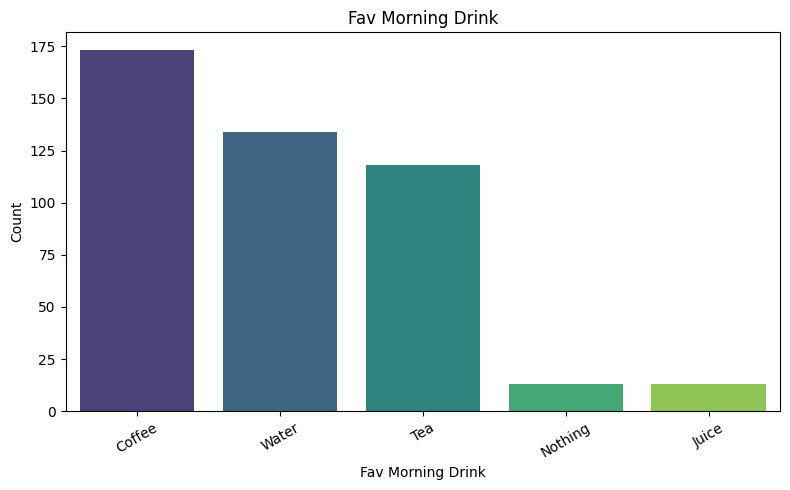

In [142]:
import seaborn as sns
import matplotlib.pyplot as plt

counts = cleaned_df["Fav Morning Drink"].value_counts()

plt.figure(figsize=(8, 5))

sns.barplot(
    x=counts.index,
    y=counts.values,
    hue=counts.index,
    palette="viridis",
    legend=False
)

plt.title("Fav Morning Drink")
plt.xlabel("Fav Morning Drink")
plt.ylabel("Count")

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [146]:
col3

'Phone Time Before Sleeping'

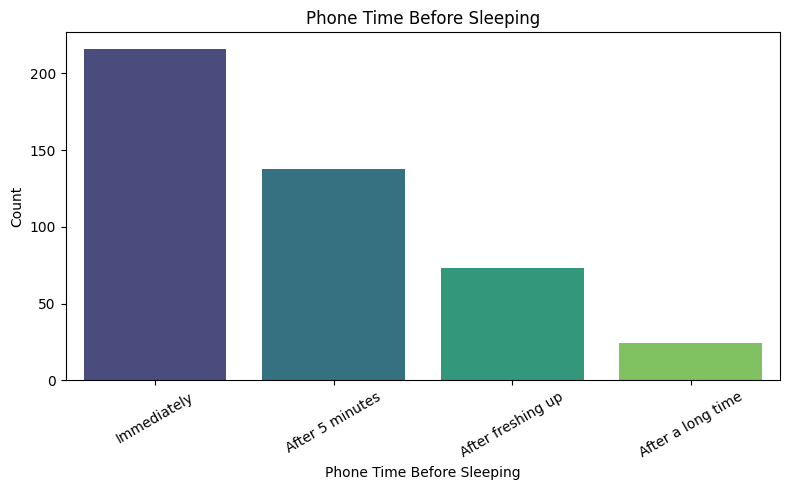

In [147]:
import seaborn as sns
import matplotlib.pyplot as plt

counts = cleaned_df["Phone Time Before Sleeping"].value_counts()

plt.figure(figsize=(8, 5))

sns.barplot(
    x=counts.index,
    y=counts.values,
    hue=counts.index,
    palette="viridis",
    legend=False
)

plt.title("Phone Time Before Sleeping")
plt.xlabel("Phone Time Before Sleeping")
plt.ylabel("Count")

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

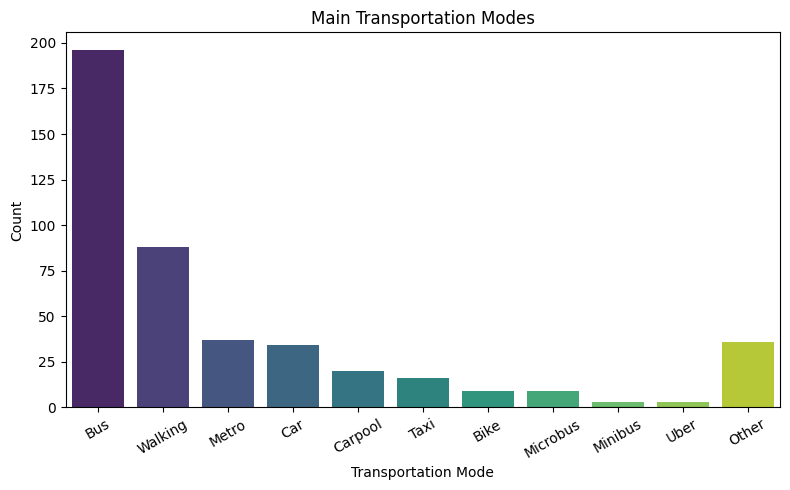

In [143]:
counts = cleaned_df["School Transport"].value_counts()

counts["Other"] = counts[counts < 3].sum()
counts = counts[counts >= 3]


plt.figure(figsize=(8, 5))

sns.barplot(
    x=counts.index,
    y=counts.values,
    hue=counts.index,
    palette="viridis",
    legend=False
)

plt.title("Main Transportation Modes")
plt.xlabel("Transportation Mode")
plt.ylabel("Count")

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()